In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

print("Cargando dataset limpio...")
df = pd.read_csv('../datos/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv')
df.columns = df.columns.str.strip()

# Limpieza
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Separar features y etiquetas
X = df.drop('Label', axis=1)
if 'Timestamp' in X.columns:
    X = X.drop('Timestamp', axis=True)

y = df['Label']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Dataset listo: {len(df):,} filas")
print(f"Features: {X.shape[1]}")
print(f"Clases: {list(le.classes_)}")

Cargando dataset limpio...
Dataset listo: 1,044,525 filas
Features: 78
Clases: ['Benign', 'Bot']


In [2]:
print("CREANDO PARTICIÓN NON-IID PARA 5 NODOS")
print("=" * 50)
print("Simulando segmentos de red de la UPEA:")
print("  Nodo 1 → Área administrativa")
print("  Nodo 2 → Laboratorios de computación")  
print("  Nodo 3 → Biblioteca y aulas")
print("  Nodo 4 → Área de docentes")
print("  Nodo 5 → Servicios institucionales")
print()

# Separar por clase
idx_benign = np.where(y_encoded == 0)[0]
idx_bot = np.where(y_encoded == 1)[0]

# Mezclar aleatoriamente
np.random.seed(42)
np.random.shuffle(idx_benign)
np.random.shuffle(idx_bot)

# Distribución Non-IID por nodo
# Cada nodo tiene diferente proporción de tráfico Bot
# Esto simula que algunos segmentos tienen más equipos infectados
config_nodos = {
    'nodo_1': {'benign_pct': 0.90, 'bot_pct': 0.10, 
                'desc': 'Área administrativa (poco Bot)'},
    'nodo_2': {'benign_pct': 0.60, 'bot_pct': 0.40, 
                'desc': 'Laboratorios (Bot moderado)'},
    'nodo_3': {'benign_pct': 0.75, 'bot_pct': 0.25, 
                'desc': 'Biblioteca y aulas (Bot bajo)'},
    'nodo_4': {'benign_pct': 0.65, 'bot_pct': 0.35, 
                'desc': 'Docentes (Bot moderado)'},
    'nodo_5': {'benign_pct': 0.50, 'bot_pct': 0.50, 
                'desc': 'Servicios (Bot alto)'},
}

# Tamaño de cada nodo (20% del total cada uno)
tam_nodo = len(df) // 5

# Crear particiones
os.makedirs('../datos/nodos', exist_ok=True)
particiones = {}
resumen_nodos = {}

benign_usado = 0
bot_usado = 0

for nombre, config in config_nodos.items():
    n_benign = int(tam_nodo * config['benign_pct'])
    n_bot = int(tam_nodo * config['bot_pct'])
    
    # Tomar índices sin repetición
    idx_b = idx_benign[benign_usado:benign_usado + n_benign]
    idx_bt = idx_bot[bot_usado:bot_usado + n_bot]
    
    benign_usado += n_benign
    bot_usado += n_bot
    
    # Combinar y mezclar
    idx_nodo = np.concatenate([idx_b, idx_bt])
    np.random.shuffle(idx_nodo)
    
    # Crear DataFrame del nodo
    X_nodo = X.iloc[idx_nodo].reset_index(drop=True)
    y_nodo = y_encoded[idx_nodo]
    
    particiones[nombre] = {
        'X': X_nodo,
        'y': y_nodo,
        'n_total': len(idx_nodo),
        'n_benign': n_benign,
        'n_bot': n_bot
    }
    
    resumen_nodos[nombre] = {
        'descripcion': config['desc'],
        'total': len(idx_nodo),
        'benign': int(n_benign),
        'bot': int(n_bot),
        'pct_bot': round(n_bot / len(idx_nodo) * 100, 1)
    }
    
    print(f"{nombre} ({config['desc']}):")
    print(f"  Total: {len(idx_nodo):,} | "
          f"Benign: {n_benign:,} | "
          f"Bot: {n_bot:,} | "
          f"Bot%: {n_bot/len(idx_nodo)*100:.1f}%")

print(f"\nTotal filas distribuidas: "
      f"{sum(p['n_total'] for p in particiones.values()):,}")

CREANDO PARTICIÓN NON-IID PARA 5 NODOS
Simulando segmentos de red de la UPEA:
  Nodo 1 → Área administrativa
  Nodo 2 → Laboratorios de computación
  Nodo 3 → Biblioteca y aulas
  Nodo 4 → Área de docentes
  Nodo 5 → Servicios institucionales

nodo_1 (Área administrativa (poco Bot)):
  Total: 208,904 | Benign: 188,014 | Bot: 20,890 | Bot%: 10.0%
nodo_2 (Laboratorios (Bot moderado)):
  Total: 208,905 | Benign: 125,343 | Bot: 83,562 | Bot%: 40.0%
nodo_3 (Biblioteca y aulas (Bot bajo)):
  Total: 208,904 | Benign: 156,678 | Bot: 52,226 | Bot%: 25.0%
nodo_4 (Docentes (Bot moderado)):
  Total: 208,904 | Benign: 135,788 | Bot: 73,116 | Bot%: 35.0%
nodo_5 (Servicios (Bot alto)):
  Total: 160,849 | Benign: 104,452 | Bot: 104,452 | Bot%: 64.9%

Total filas distribuidas: 996,466


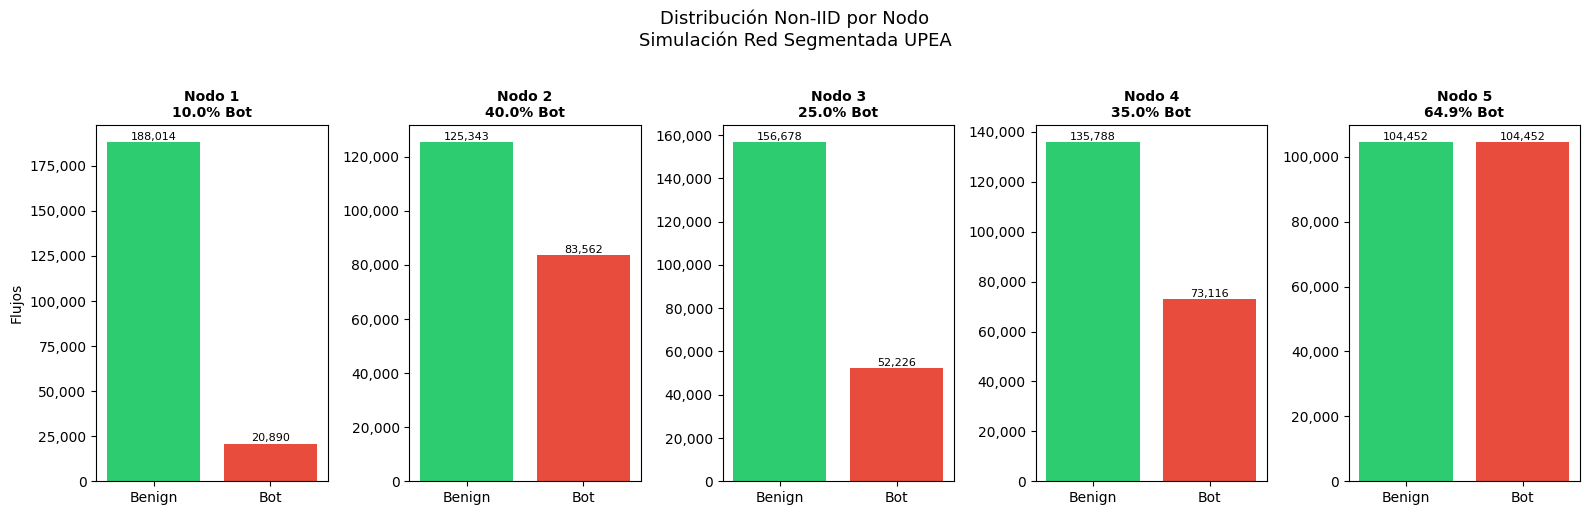

Gráfico guardado ✓

Este gráfico va en la sección 3.2 de tu tesis:
'Diseño del experimento federado - partición Non-IID'


In [3]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle('Distribución Non-IID por Nodo\nSimulación Red Segmentada UPEA', 
             fontsize=13, y=1.02)

colores = ['#2ecc71', '#e74c3c']

for i, (nombre, data) in enumerate(resumen_nodos.items()):
    ax = axes[i]
    valores = [data['benign'], data['bot']]
    barras = ax.bar(['Benign', 'Bot'], valores, color=colores)
    
    ax.set_title(f"Nodo {i+1}\n{data['pct_bot']}% Bot", 
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Flujos' if i == 0 else '')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2., 
                barra.get_height() + 100,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../resultados/distribucion_nodos_noniid.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")
print("\nEste gráfico va en la sección 3.2 de tu tesis:")
print("'Diseño del experimento federado - partición Non-IID'")

In [4]:
print("Guardando particiones en disco...")
print("(Esto permite que el experimento federado las cargue rápidamente)")

for nombre, data in particiones.items():
    # Combinar X e y en un DataFrame
    df_nodo = data['X'].copy()
    df_nodo['Label'] = data['y']
    
    # Guardar como CSV
    ruta = f'../datos/nodos/{nombre}.csv'
    df_nodo.to_csv(ruta, index=False)
    tamaño = os.path.getsize(ruta) / 1024**2
    print(f"  {nombre}.csv guardado ({tamaño:.1f} MB)")

# Guardar resumen
with open('../resultados/resumen_nodos.json', 'w') as f:
    json.dump(resumen_nodos, f, indent=2, ensure_ascii=False)

print("\nResumen guardado en resultados/resumen_nodos.json ✓")
print("\nEstructura de datos/nodos/:")
for archivo in os.listdir('../datos/nodos/'):
    ruta = f'../datos/nodos/{archivo}'
    tam = os.path.getsize(ruta) / 1024**2
    print(f"  {archivo} ({tam:.1f} MB)")

Guardando particiones en disco...
(Esto permite que el experimento federado las cargue rápidamente)
  nodo_1.csv guardado (73.9 MB)
  nodo_2.csv guardado (71.7 MB)
  nodo_3.csv guardado (72.7 MB)
  nodo_4.csv guardado (72.1 MB)
  nodo_5.csv guardado (55.5 MB)

Resumen guardado en resultados/resumen_nodos.json ✓

Estructura de datos/nodos/:
  nodo_1.csv (73.9 MB)
  nodo_2.csv (71.7 MB)
  nodo_3.csv (72.7 MB)
  nodo_4.csv (72.1 MB)
  nodo_5.csv (55.5 MB)


In [5]:
print("VERIFICACIÓN DE PARTICIONES")
print("=" * 50)

for nombre in config_nodos.keys():
    df_verificar = pd.read_csv(f'../datos/nodos/{nombre}.csv')
    n_benign = (df_verificar['Label'] == 0).sum()
    n_bot = (df_verificar['Label'] == 1).sum()
    
    print(f"{nombre}: {len(df_verificar):,} filas | "
          f"Benign: {n_benign:,} | "
          f"Bot: {n_bot:,} | "
          f"Bot%: {n_bot/len(df_verificar)*100:.1f}%")

print("\n✓ Particiones verificadas y listas para el experimento federado")
print("\nPróximo paso: implementar el servidor y clientes Flower")

VERIFICACIÓN DE PARTICIONES
nodo_1: 208,904 filas | Benign: 188,014 | Bot: 20,890 | Bot%: 10.0%
nodo_2: 208,905 filas | Benign: 125,343 | Bot: 83,562 | Bot%: 40.0%
nodo_3: 208,904 filas | Benign: 156,678 | Bot: 52,226 | Bot%: 25.0%
nodo_4: 208,904 filas | Benign: 135,788 | Bot: 73,116 | Bot%: 35.0%
nodo_5: 160,849 filas | Benign: 104,452 | Bot: 56,397 | Bot%: 35.1%

✓ Particiones verificadas y listas para el experimento federado

Próximo paso: implementar el servidor y clientes Flower


In [6]:
import subprocess

result = subprocess.run(
    ['git', 'add', '.'],
    cwd='C:/tesis-fl-ids',
    capture_output=True, text=True
)

result = subprocess.run(
    ['git', 'commit', '-m', 
     'feat: particion non-iid 5 nodos dataset CIC-IDS-2018'],
    cwd='C:/tesis-fl-ids',
    capture_output=True, text=True
)
print(result.stdout)

result = subprocess.run(
    ['git', 'push'],
    cwd='C:/tesis-fl-ids',
    capture_output=True, text=True
)
print(result.stdout if result.returncode == 0 else result.stderr)

[main b6138d6] feat: particion non-iid 5 nodos dataset CIC-IDS-2018
 3 files changed, 37 insertions(+)
 create mode 100644 notebooks/04_particion_federada.ipynb
 create mode 100644 resultados/distribucion_nodos_noniid.png
 create mode 100644 resultados/resumen_nodos.json


